In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)

In [2]:
eid_pheno_matrix <- read.table("/well/lindgren-ukbb/projects/ukbb-11867/samvida/general_resources/eid_phenotype_matrix.txt",
                             sep = "\t", header = T, stringsAsFactors = F)
colnames(eid_pheno_matrix) <- gsub("^X", "", colnames(eid_pheno_matrix))

# Disease dictionary
dictionary <- read.table("/well/lindgren-ukbb/projects/ukbb-11867/samvida/general_resources/UKB_codelists/chronological-map-phenotypes/annot_dictionary.txt",
                         sep = "\t", header = T, stringsAsFactors = F, 
                         quote = "", comment.char = "$")
PHENOTYPES <- dictionary$phenotype[match(colnames(eid_pheno_matrix)[-1],
                                       dictionary$unique_code)]
colnames(eid_pheno_matrix)[-1] <- PHENOTYPES

In [3]:
main <- fread('/well/lindgren/UKBIOBANK/dpalmer/ukb_wes_phenotypes/curated_phenotypes_binary.tsv')

In [4]:
samples <- fread("/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/samples/09_final_qc.keep.sample_list")$V1

In [5]:
d <- fread("/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/samples/09_final_qc.keep.sample_list")

In [39]:
# load spiro phenotypes based on Samvida's paths
get_spiro_phenos <- function(){
    
    # setup paths
    path_phenotype_matrix <- "/well/lindgren-ukbb/projects/ukbb-11867/samvida/general_resources/eid_phenotype_matrix.txt"
    path_disease_dict <- "/well/lindgren-ukbb/projects/ukbb-11867/samvida/general_resources/UKB_codelists/chronological-map-phenotypes/annot_dictionary.txt"
    stopifnot(file.exists(path_phenotype_matrix))
    stopifnot(file.exists(path_disease_dict))
    
    # load main phenotype matrix
    eid_pheno_matrix <- read.table(
        path_phenotype_matrix,
        sep = "\t", 
        header = T,
        stringsAsFactors = F
    )
    colnames(eid_pheno_matrix) <- gsub("^X", "", colnames(eid_pheno_matrix))
    
    # Disease dictionary
    dictionary <- read.table(
        path_disease_dict,
        sep = "\t", 
        header = T, 
        stringsAsFactors = F,
        quote = "", 
        comment.char = "$")
    PHENOTYPES <- dictionary$phenotype[match(colnames(eid_pheno_matrix)[-1], dictionary$unique_code)]
    colnames(eid_pheno_matrix)[-1] <- PHENOTYPES
    return(eid_pheno_matrix)
    
}

# load brava phenotypes based on Duncan's paths
get_brava_phenos <- function(){
    
    # paths
    path_phenotypes <- "/well/lindgren/UKBIOBANK/dpalmer/superpopulation_assignments/BRaVa_phenotypes_with_superpopulation_labels.tsv"
    eid_pheno_matrix <- fread(path_phenotypes)
    
    # remove columns not needed
    eid_pheno_matrix$ICD9_string <- NULL
    eid_pheno_matrix$ICD10_string <- NULL
    
    # we remove everything after classifcation column
    idx_keep <- 1:which(grepl('classification', colnames(eid_pheno_matrix)))[1]-1
    eid_pheno_matrix <- eid_pheno_matrix[,..idx_keep]
    
    
    return(eid_pheno_matrix)
    
}

# clean header
to_unix_friendly_colnames <- function(names){
    cols <- gsub("\\'", "", names)
    cols <- gsub("\\(.+\\)","", cols) 
    cols <- gsub('\\"', "", cols)
    cols <- gsub("\\-","_", cols)
    cols <- gsub("\\&", "_and_", cols)
    cols <- gsub("\\,","_",cols)
    cols <- gsub("(^\\ *)|(\\ *$)","", cols)
    cols <- gsub("\\/", "_", cols)
    # preserve unicode charcaters
    cols <- stringi::stri_trans_general(cols, "latin-ascii")
    # clean up spaces
    cols <- gsub("\\ +", " ", cols)
    cols <- gsub("\\ ", "_", cols)
    cols <- gsub("\\_+", "_", cols)
    cols <- tolower(cols)
    return(cols)
}

In [42]:
spiro <- get_spiro_phenos()
spiro[,-1] <- spiro[,-1] > 0
colnames(spiro) <- to_unix_friendly_colnames(colnames(spiro))

In [53]:
head(spiro)

,eid,abdominal_hernia,abdominal_aortic_aneurysm,acne,actinic_keratosis,acute_kidney_injury,agranulocytosis,alcohol_problems,alcoholic_liver_disease,allergic_and_chronic_rhinitis,⋯,visual_impairment_and_blindness,vitamin_b12_deficiency_anaemia,vitiligo,volvulus,chronic_kidney_disease,low_hdl_c,raised_ldl_c,raised_total_cholesterol,raised_triglycerides,type_2_diabetes
,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,1000028,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,⋯,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
2,1000034,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,⋯,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
3,1000045,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,⋯,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
4,1000069,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,⋯,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
5,1000087,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,⋯,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
6,1000091,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,⋯,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


In [7]:
brava <- get_brava_phenos()

In [8]:
brava[,2:ncol(brava)] <- brava[,2:ncol(brava)] > 0

Warning message in `[<-.data.table`(`*tmp*`, , 2:ncol(brava), value = structure(c(FALSE, :
"110 column matrix RHS of := will be treated as one vector"


In [9]:
brava <- get_brava_phenos()
#brava[,-1] <- brava[,-1] > 0
#colnames(brava) <- colnames(brava))

In [40]:
test <- data.frame(colnames(brava)[-1], to_unix_friendly_colnames(colnames(brava)[-1]))

In [41]:
test[grepl("gren",test[,2]),][,2]

[1] "primary_sjogren_syndrome"

In [42]:
uni <- test[grepl("gren",test[,2]),][,2]

In [ ]:
mrg <- merge(dt, spiros_pheno, by = "eid", all.x = TRUE)

In [55]:
args <- list()
args$input_path <- "/well/lindgren/UKBIOBANK/dpalmer/ukb_wes_phenotypes/curated_phenotypes_binary.tsv"
main <- fread(args$input_path)

In [58]:
brava <- get_brava_phenos()
colnames(brava)

[1] "eid"                                                        
  [2] "Gout"                                                       
  [3] "Coronary artery disease"                                    
  [4] "Male infertility"                                           
  [5] "Female infertility"                                         
  [6] "Female infertility (anatomic causes only)"                  
  [7] "Uterine cancer (UtC)"                                       
  [8] "Thyroid cancer (ThC)"                                       
  [9] "Primary open angle glaucoma (POAG)"                         
 [10] "Cardiomyopathy(hypertrophic, obstructive) (HCM)"            
 [11] "Heart Failure (HF)"                                         
 [12] "Stroke (Stroke)"                                            
 [13] "Abdominal aortic aneurysm (AAA)"                            
 [14] "Asthma (Asthma)"                                            
 [15] "Chronic obstructive pulmonary disease (COPD)"               
 [16] "Acute appendicitis (AcApp)"                                 
 [17] "Idiopathic pulmonary fibrosis (IPF)"                        
 [18] "Venous Thromboembolism (VTE)"                               
 [19] "Myalgic Encephalomyelitis/Chronic Fatigue Syndrome (ME/CFS)"
 [20] "AL amyloidosis"                                             
 [21] "B-cell chronic lymphocytic leukemia"                        
 [22] "Brugada syndrome"                                           
 [23] "Bullous pemphigoid"                                         
 [24] "Cardiogenic shock"                                          
 [25] "Central retinal vein occlusion"                             
 [26] "Corpus callosum agenesis-neuronopathy syndrome"             
 [27] "Essential thrombocythemia"                                  
 [28] "Familial spontaneous pneumothorax"                          
 [29] "Follicular lymphoma"                                        
 [30] "Immune thrombocytopenia"                                    
 [31] "Narcolepsy type 1"                                          
 [32] "Non-functioning pituitary adenoma"                          
 [33] "Non-papillary transitional cell carcinoma of the bladder"   
 [34] "Osteochondritis dissecans"                                  
 [35] "Placental insufficiency"                                    
 [36] "Polycythemia vera"                                          
 [37] "Preeclampsia"                                               
 [38] "Primary Sj\303\266gren syndrome"                            
 [39] "Prolactinoma"                                               
 [40] "Romano-Ward syndrome"                                       
 [41] "Sarcoidosis"                                                
 [42] "Spina bifida aperta"                                        
 [43] "Systemic lupus erythematosus"                               
 [44] "Acute lymphoid leukemia"                                    
 [45] "Age-related macular degeneration"                           
 [46] "Anorexia nervosa"                                           
 [47] "Benign and in situ cervical and uterine neoplasms"          
 [48] "Benign and in situ intestinal neoplasms"                    
 [49] "Bladder cancer"                                             
 [50] "Brain and central nervous system cancer"                    
 [51] "Bulimia nervosa"                                            
 [52] "Cervical cancer"                                            
 [53] "Chronic myeloid leukemia"                                   
 [54] "Colon and rectum cancer"                                    
 [55] "Eating disorders"                                           
 [56] "Endocarditis"                                               
 [57] "Endometriosis"                                              
 [58] "Adenomyosis"                                                
 [59] "Excess, frequent and irregular menstrual bleeding" 

In [59]:
colnames(brava)[grepl("inf",colnames(brava))]

[1] "Male infertility"                         
[2] "Female infertility"                       
[3] "Female infertility (anatomic causes only)"

In [54]:
# combine phenotypes based on main file
mrg <- merge(main, spiro by = "eid", all.x = TRUE)
mrg <- merge(mrg, brava, by = "eid", all.x = TRUE)

In [61]:
# determine overlap between old phenotypes and new phenotypes
pheno_cols <- names(which(sapply(mrg, is.logical)))

In [82]:
# discard phenotypes with less than 50 cases in quality controlled samples (200k)
mrg_subset_by_qced_samples <- mrg[mrg$eid %in% samples,]
lst <- lapply(pheno_cols, function(ph) sum(mrg_subset_by_qced_samples[[ph]], na.rm = TRUE))
names(lst) <- pheno_cols
dlst <- stack(lst)
colnames(dlst) <- c("cases", "phenotype")
bool_phenos_discard <- dlst$cases < 50
dlst <- dlst[!bool_phenos_discard, ]
write(paste("Discarded", sum(bool_phenos_discard), "phenotypes with less than 50 cases."), stdout())
phenos_keep <- dlst$phenotype

Discarded 27 phenotypes with less than 50 cases.


In [89]:
cols_keep <- (!(colnames(mrg) %in% pheno_cols)) | (colnames(mrg) %in% phenos_keep)
mrg <- mrg[,..cols_keep]
nrow(mrg)

[1] 502617

In [35]:
M <- colSums(eid_pheno_matrix[eid_pheno_matrix$eid %in% samples,])

In [36]:
x <- seq(1, 2000, by = 10)
y <- unlist(lapply(x, function(xi) sum(M > xi)))

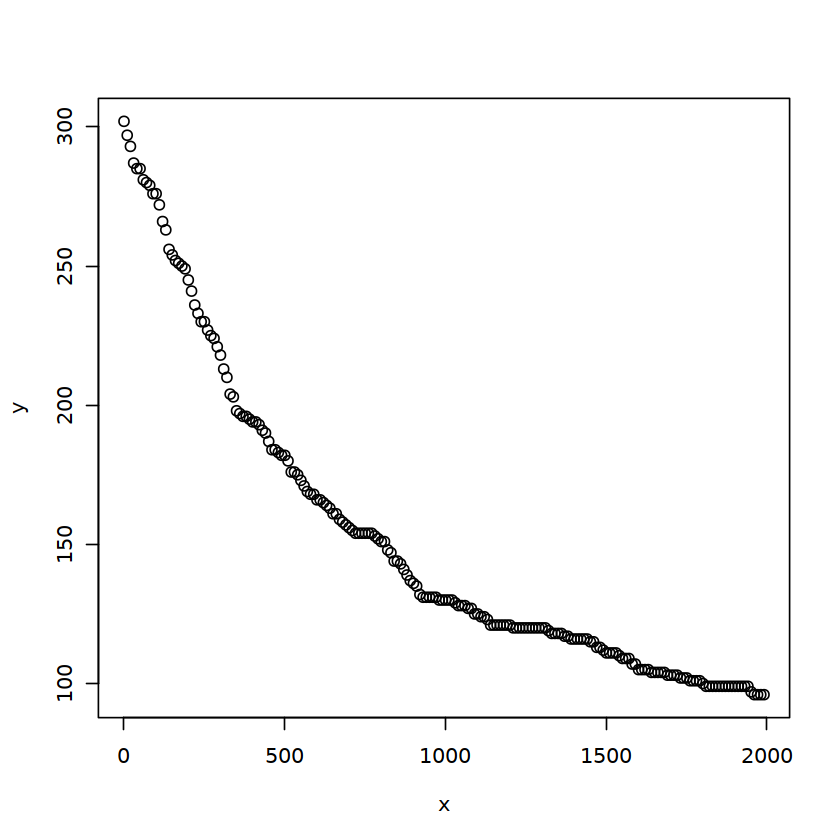

In [39]:
plot(x, y)

In [41]:
args <- list()
args$chrom = "chr1"

args$enable_cond_pipeline = TRUE

args$input_path = "data/permute/genes/phased_only/chr1/ukb_eur_wes_200k_pLoF_damaging_missense_chr1_ENSG00000132781.tsv.gz"

args$input_path_cond_genotypes = "data/conditional/common/markers_with_gt/final/common_conditional.tsv.gz"

args$only_non_prob_ko = FALSE

args$out_prefix = "data/permute/permutations/chr1/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr1_ENSG00000132781_1"

args$permutations = "100"

args$remove_invariant_markers = TRUE

args$seed = "3"
args$vcf_id ="ENSG00000132781"
args

$chrom
[1] "chr1"

$enable_cond_pipeline
[1] TRUE

$input_path
[1] "data/permute/genes/phased_only/chr1/ukb_eur_wes_200k_pLoF_damaging_missense_chr1_ENSG00000132781.tsv.gz"

$input_path_cond_genotypes
[1] "data/conditional/common/markers_with_gt/final/common_conditional.tsv.gz"

$only_non_prob_ko
[1] FALSE

$out_prefix
[1] "data/permute/permutations/chr1/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr1_ENSG00000132781_1"

$permutations
[1] "100"

$remove_invariant_markers
[1] TRUE

$seed
[1] "3"

$vcf_id
[1] "ENSG00000132781"

In [43]:
library(argparse)
library(data.table)

# simple method to shuffle knockouts
shuffle_knockouts <- function(d){
    d$KO <- rbinom(n=nrow(d), size=1, prob = d$pTKO)
    d$pKO <- ifelse((d$KO == 1 & d$unphased_het == 0), 1,
         ifelse((d$KO == 1 & d$hom_alt_n > 0), 1,
         ifelse((d$phased_het == 1 & d$unphased_het > 0), 1 - 1*(1/2)^d$unphased_het,
         ifelse((d$phased_het == 0 & d$unphased_het > 1), 1 - 2*(1/2)^d$unphased_het, 0))))
    return(d$pKO)
}

# make header of VCF file
make_vcf_dosage_header <- function(chrom){
    vcf_format <- '##fileformat=VCFv4.2'
    vcf_entry <-  '##FORMAT=<ID=DS,Number=1,Type=Float,Description="">'
    vcf_filter <- '##FILTER=<ID=PASS,Description="All filters passed">"'
    vcf_contig <- paste0('##contig=<ID=',chrom,',length=81195210>')
    vcf_out <- paste(vcf_format, vcf_entry, vcf_filter, vcf_contig, sep = '\n')
    return(vcf_out)
}


# make a random string of n characters and numbers
random_string <- function(n){
    return(paste0(sample(c(letters, LETTERS), n, replace = TRUE), collapse = ""))
}

# make vcf-like rows for dosage entries
make_vcf_dosage_rows <- function(chrom, positions, marker, use_random_alleles = TRUE){
    rows <- length(positions)
    refs <- unlist(ifelse(use_random_alleles, list(replicate(rows, random_string(4))), "A0"))
    alts <- unlist(ifelse(use_random_alleles, list(replicate(rows, random_string(4))), "A1"))
    return(data.table(
      "#CHROM" = chrom,
      POS = positions,
      ID = marker,
      REF = refs,
      ALT = alts,
      QUAL = '.',
      FILTER = '.',
      INFO = '.',
      FORMAT = 'DS'
    ))
}

# read real variant data in long format (exported from hail)
# note: need position_last argument, since make_tabix will otherwise complain
# that the positions are not sorted.
format_real_variant_long_to_wide <- function(dt, position_last = 20000){

    stopifnot("s" %in% colnames(dt))
    stopifnot("locus" %in% colnames(dt))
    stopifnot("rsid" %in% colnames(dt))
    stopifnot("alleles" %in% colnames(dt))

    mapping <- dt[,c("locus","alleles","rsid")]
    mapping <- mapping[!duplicated(mapping),]

    # create mapping rows that are to be combined with actual dosages
    alleles <- as.data.frame(do.call(rbind, strsplit(gsub('(")|(\\])|(\\[)','',mapping$alleles), split = ',')))
    colnames(alleles) <- c("REF","ALT")
    mapping <- cbind(mapping, alleles)
    mapping$positions_recoded <- (position_last+1):(position_last+nrow(mapping))
    mapping$positions <- gsub("chr[0-9]+\\:", "",mapping$locus)
    mapping$marker <- paste0(mapping$locus, ":", mapping$REF, ":", mapping$ALT)
    mapping$chroms <- stringr::str_extract(mapping$locus, "chr[0-9]+")
    stopifnot(length(unique(mapping$positions)) == length(mapping$positions)) # can't handle SNPs at same pos
    mapping_rows <- data.table(
        "#CHROM" = mapping$chroms,
          POS = mapping$positions,
          ID = mapping$rsid,
          REF = mapping$REF,
          ALT = mapping$ALT,
          QUAL = '.',
          FILTER = '.',
          INFO = '.',
          FORMAT = 'DS',
          locus = mapping$locus
    )

    # go from long to wide format
    dt <- dt[,c('locus','s','DS')]
    dt <- data.table::dcast(locus~s, data = dt, value.var = "DS")

    # match mapping rows with dt rows
    #new_index <- match(dt$locus, mapping$locus)
    new_index <- match(mapping$locus, dt$locus)
    mapping_rows$locus <- NULL
    #mapping_rows <- mapping_rows[new_index,]
    dt <- dt[new_index,]

    #return(cbind(mapping_rows, dt))
    return(list(rows = mapping_rows, dosages = dt))

}


In [62]:
autosomes <- paste0("chr",1:22)
stopifnot(file.exists(args$input_path))
stopifnot(!is.na(as.numeric(args$permutations)))
stopifnot(!is.null(args$permutations))
stopifnot(!is.null(args$vcf_id))
stopifnot(args$chrom %in% autosomes)
stopifnot(!is.null(args$enable_cond_pipeline))
# conditional pipeline
if (args$enable_cond_pipeline) {
  cpath = args$input_path_cond_genotypes
  if (!file.exists(cpath)){
    stop(paste("Can't find conditional markers at: ", cpath))
  }
}

# seed for reproducibility
seed <- as.numeric(args$seed)
set.seed(seed)

# replicate knockout
n <- as.numeric(args$permutations)
d <- fread(args$input_path)
stopifnot(nrow(d) > 0)
reps <- replicate(n, shuffle_knockouts(d))
rownames(reps) <- d$s
reps <- data.table(t(reps))

# convert to dosage
dosage <- reps * 2

# only keep non-probabilistic knockouts
if (args$only_non_prob_ko) dosage[dosage < 2] <- 0


# load real conditioning variants, i.e. the actual
# dosages/genotypes of the variants that we would like
# to condition on
if (args$enable_cond_pipeline) {
  cond_dt <- fread(args$input_path_cond_genotypes)
  cond_dt$chr <- stringr::str_extract(cond_dt$locus, "chr[0-9]+")
  cond_dt <- cond_dt[cond_dt$chr %in% args$chrom]
  n_real_markers <- length(unique(cond_dt$locus))
} else {
  n_real_markers <- 0
}


In [64]:
# how many markers were found?
        write(paste("Note:",n_real_markers, "real marker(s) found. These will be included as unshuffled in permuted VCF."),stdout())

        # ensure that samples are overlapping
        sample_overlap <- unique(intersect(cond_dt$s, d$s))

        # subset dosage matrix (with permuted phased)
        rows <- make_vcf_dosage_rows(args$chrom, 1:n, args$vcf_id)
        dosage <- dosage[,colnames(dosage) %in% sample_overlap, with = FALSE]

        # subset real dosage matrix (with actual calls/DS)
        cond_dt <- cond_dt[cond_dt$s %in% sample_overlap,]
        cond_lst <- format_real_variant_long_to_wide(cond_dt, n)

        # get long format
        cond_rows <- cond_lst$rows
        cond_dosage <- cond_lst$dosage

        # match columns
        cond_dosage$locus <- NULL
        cond_dosage <- cond_dosage[,colnames(dosage), with = FALSE]

        # combine columns and rows. Note: that rbind order
        # matters here when using tabix!
        stopifnot(ncol(rows) == ncol(cond_rows))
        combined_dosages <- rbind(dosage, cond_dosage)
        combined_meta <- rbind(rows, cond_rows)
        final <- cbind(combined_meta, combined_dosages)
        sds <- unlist(apply(combined_dosages, 1, function(x) sd(x, na.rm = TRUE)))

        # how many real markers have missing dosages
        n_real_count <- nrow(cond_dosage)
        n_real_miss <- sum(is.na(apply(cond_dosage, 1, sd)))
        write(paste0("Note: ", n_real_miss, " of ", n_real_count, " have one or more missing dosages."), stdout())

        # debugging - are SNPs monoprhic and thus
        # the resulting matrix not invertible?
        #cond_dosage_sd <- apply(cond_dosage, 1, sd)
        #cond_dosage_af <- apply(cond_dosage, 1, mean)
        #cond_rows$sd <- cond_dosage_sd
        #cond_rows$af <- cond_dosage_af

Note: 27 real marker(s) found. These will be included as unshuffled in permuted VCF.
Note: 7 of 27 have one or more missing dosages.


In [65]:
any(is.na(sds))

[1] FALSE

In [57]:
d[,as.logical(d[1,is.na(d[1,])]), with = FALSE]

2543193,2629798,3807322,4040775
<dbl>,<dbl>,<dbl>,<dbl>
NA,NA,NA,NA
0,2,0,0
1,0,0,0
2,1,1,0
0,1,0,0
1,1,0,1
0,0,0,0


In [181]:
gene="ENSG00000132781"
path="data/permute/overview/min_mac4/phased_only/main_true_p.tsv.gz"
phenotype="CC_combined"
placeholder="ukb_eur_wes_200k_maf0to5e-2_PHENO_ANNO"
annotation="pLoF_damaging_missense"
use_prs <- TRUE

In [182]:
d <- fread(path)

In [192]:
# subset by phenotype and annotation
bool_phenotype <- d$phenotype %in% phenotype
bool_gene <- d$MarkerID %in% gene
bool_annotation <- d$annotation %in% annotation

# first check
if (!any(bool_phenotype)) stop(paste0("No P-values for phenotype: ", phenotype))
if (!any(bool_phenotype)) stop(paste0("No P-values for gene: ", gene))
if (!any(bool_phenotype)) stop(paste0("No P-values for Annotation: ", annotation))

# subset by PRS
d1 <- d[(bool_phenotype & bool_annotation & bool_gene),]
bool_prs <- (!is.na(d1$prs))
if ((use_prs) & sum(bool_prs) > 0){
    d1 <- d1[bool_prs,]
    write(paste0("Using PRS for ", phenotype), stderr())
} 

# check that we have at least one row.
if (nrow(d1) > 1) stop("Ambigious input specifications! Too many markers found.")
if (nrow(d1) == 0) stop(paste("No markers found for combination:", phenotype, gene, annotation))

if (target == "p"){
    return(d1$pvalue)
} else if (target == "t"){
    return(d1$tstat)
} else {
    stop(paste(target, "is not a valid parameter to return!"))
}






ERROR: Error in eval(expr, envir, enclos): object 'target' not found


CHR,MarkerID,p.value,Tstat,p.value_c,Tstat_c,phenotype,annotation,prs,pvalue,tstat
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
chr1,ENSG00000132781,2.302899e-42,18.9754,NA,NA,CC_combined,pLoF_damaging_missense,locoprs,2.302899e-42,18.9754


In [122]:
stopifnot(all(grepl(basename_prefix, d$basename)))
stopifnot(all(grepl(basename_annotation, d$basename)))
basename_minimal <- gsub(basename_prefix, "", d$basename)
basename_minimal <- gsub(basename_annotation, "", basename_minimal)
basename_minimal <- gsub(basename_locoprs, "", basename_minimal)
phenotype <- gsub("(^\\_*)|(\\_*$)","",basename_minimal)

In [123]:
stringr::str_extract_all(d$basename,basename_annotation)

[[1]]
[1] "pLoF_damaging_missense"

[[2]]
[1] "pLoF_damaging_missense"

[[3]]
[1] "pLoF_damaging_missense"

[[4]]
[1] "pLoF_damaging_missense"

[[5]]
[1] "pLoF_damaging_missense"

[[6]]
[1] "pLoF_damaging_missense"

[[7]]
[1] "pLoF_damaging_missense"

[[8]]
[1] "pLoF_damaging_missense"

[[9]]
[1] "pLoF_damaging_missense"

[[10]]
[1] "pLoF_damaging_missense"

[[11]]
[1] "pLoF_damaging_missense"

[[12]]
[1] "pLoF_damaging_missense"

[[13]]
[1] "pLoF_damaging_missense"

[[14]]
[1] "pLoF_damaging_missense"

[[15]]
[1] "pLoF_damaging_missense"

[[16]]
[1] "pLoF_damaging_missense"

[[17]]
[1] "pLoF_damaging_missense"

[[18]]
[1] "pLoF_damaging_missense"

[[19]]
[1] "pLoF_damaging_missense"

[[20]]
[1] "pLoF_damaging_missense"

[[21]]
[1] "pLoF_damaging_missense"

[[22]]
[1] "pLoF_damaging_missense"

[[23]]
[1] "pLoF_damaging_missense"

[[24]]
[1] "pLoF_damaging_missense"

[[25]]
[1] "pLoF_damaging_missense"

[[26]]
[1] "pLoF_damaging_missense"

[[27]]
[1] "pLoF_damaging_missense"

[[28]]
[1] "pLoF_damaging_missense"

[[29]]
[1] "pLoF_damaging_missense"

[[30]]
[1] "pLoF_damaging_missense"

[[31]]
[1] "pLoF_damaging_missense"

[[32]]
[1] "pLoF_damaging_missense"

[[33]]
[1] "pLoF_damaging_missense"

[[34]]
[1] "pLoF_damaging_missense"

[[35]]
[1] "pLoF_damaging_missense"

[[36]]
[1] "pLoF_damaging_missense"

[[37]]
[1] "pLoF_damaging_missense"

[[38]]
[1] "pLoF_damaging_missense"

[[39]]
[1] "pLoF_damaging_missense"

[[40]]
[1] "pLoF_damaging_missense"

[[41]]
[1] "pLoF_damaging_missense"

[[42]]
[1] "pLoF_damaging_missense"

[[43]]
[1] "pLoF_damaging_missense"

[[44]]
[1] "pLoF_damaging_missense"

[[45]]
[1] "pLoF_damaging_missense"

[[46]]
[1] "pLoF_damaging_missense"

[[47]]
[1] "pLoF_damaging_missense"

[[48]]
[1] "pLoF_damaging_missense"

[[49]]
[1] "pLoF_damaging_missense"

[[50]]
[1] "pLoF_damaging_missense"

[[51]]
[1] "pLoF_damaging_missense"

[[52]]
[1] "pLoF_damaging_missense"

[[53]]
[1] "pLoF_damaging_missense"

[[54]]
[1] "pLoF_damaging_missense"

[[55]]
[1] "pLoF_damaging_missense"

[[56]]
[1] "pLoF_damaging_missense"

[[57]]
[1] "pLoF_damaging_missense"

[[58]]
[1] "pLoF_damaging_missense"

[[59]]
[1] "pLoF_damaging_missense"

[[60]]
[1] "pLoF_damaging_missense"

[[61]]
[1] "pLoF_damaging_missense"

[[62]]
[1] "pLoF_damaging_missense"

[[63]]
[1] "pLoF_damaging_missense"

[[64]]
[1] "pLoF_damaging_missense"

[[65]]
[1] "pLoF_damaging_missense"

[[66]]
[1] "pLoF_damaging_missense"

[[67]]
[1] "pLoF_damaging_missense"

[[68]]
[1] "pLoF_damaging_missense"

[[69]]
[1] "pLoF_damaging_missense"

[[70]]
[1] "pLoF_damaging_missense"

[[71]]
[1] "pLoF_damaging_missense"

[[72]]
[1] "pLoF_damaging_missense"

[[73]]
[1] "pLoF_damaging_missense"

[[74]]
[1] "pLoF_damaging_missense"

[[75]]
[1] "pLoF_damaging_missense"

[[76]]
[1] "pLoF_damaging_missense"

[[77]]
[1] "pLoF_damaging_missense"

[[78]]
[1] "pLoF_damaging_missense"

[[79]]
[1] "pLoF_damaging_missense"

[[80]]
[1] "pLoF_damaging_missense"

[[81]]
[1] "pLoF_damaging_missense"

[[82]]
[1] "pLoF_damaging_missense"

[[83]]
[1] "pLoF_damaging_missense"

[[84]]
[1] "pLoF_damaging_missense"

[[85]]
[1] "pLoF_damaging_missense"

[[86]]
[1] "pLoF_damaging_missense"

[[87]]
[1] "pLoF_damaging_missense"

[[88]]
[1] "pLoF_damaging_missense"

[[89]]
[1] "pLoF_damaging_missense"

[[90]]
[1] "pLoF_damaging_missense"

[[91]]
[1] "pLoF_damaging_missense"

[[92]]
[1] "pLoF_damaging_missense"

[[93]]
[1] "pLoF_damaging_missense"

[[94]]
[1] "pLoF_damaging_missense"

[[95]]
[1] "pLoF_damaging_missense"

[[96]]
[1] "pLoF_damaging_missense"

[[97]]
[1] "pLoF_damaging_missense"

[[98]]
[1] "pLoF_damaging_missense"

[[99]]
[1] "pLoF_damaging_missense"

[[100]]
[1] "pLoF_damaging_missense"

[[101]]
[1] "pLoF_damaging_missense"

[[102]]
[1] "pLoF_damaging_missense"

[[103]]
[1] "pLoF_damaging_missense"

[[104]]
[1] "pLoF_damaging_missense"

[[105]]
[1] "pLoF_damaging_missense"

[[106]]
[1] "pLoF_damaging_missense"

[[107]]
[1] "pLoF_damaging_missense"

[[108]]
[1] "pLoF_damaging_missense"

[[10